# 04. SHAP Explainability
## IBM Telco Customer Churn

**Goal:** Go beyond aggregate feature importance and explain *why* the model
predicts churn for specific customers.

Feature importance (notebook 03) answers: "Which features matter overall?"
SHAP answers: "Why did the model score *this* customer at 78% churn probability?"

That distinction matters for the business. A retention team cannot act on
"contract type is important." They can act on "this customer's month-to-month
contract increased their churn probability by 0.32."

**What this notebook produces:**

1. Global summary: which features drive churn across all customers
2. Feature direction: does high tenure *increase* or *decrease* churn probability?
3. Individual explanations: waterfall plots for a high-risk and a low-risk customer
4. Dependence plots: how SHAP value changes as a feature value changes
5. Business interpretation: translate SHAP findings into actionable segments


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import pickle, json, os, warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
shap.initjs()

FIG_DIR   = "../outputs/figures"
MODEL_DIR = "../outputs/models"
os.makedirs(FIG_DIR, exist_ok=True)

print("Imports complete.")


Imports complete.


---
## 1. Load Model and Features


In [2]:
# Load model artifacts
with open(f"{MODEL_DIR}/xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(f"{MODEL_DIR}/feature_columns.json") as f:
    feature_cols = json.load(f)

with open(f"{MODEL_DIR}/model_metadata.json") as f:
    metadata = json.load(f)

print(f"Model       : {metadata['model']}")
print(f"ROC-AUC     : {metadata['roc_auc_test']}")
print(f"Threshold   : {metadata['optimal_threshold']}")
print(f"N features  : {metadata['n_features']}")


Model       : XGBoost
ROC-AUC     : 0.8476
Threshold   : 0.29
N features  : 22


In [3]:
# Load features and target
X = pd.read_csv("../outputs/X_features.csv")[feature_cols]
y = pd.read_csv("../outputs/y_target.csv").squeeze()

# Impute any NaN (consistent with modeling notebook)
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print(f"X shape: {X.shape}")
print(f"Churn rate: {y.mean()*100:.1f}%")


X shape: (7043, 22)
Churn rate: 26.5%


---
## 2. SHAP TreeExplainer

`shap.TreeExplainer` is purpose-built for tree-based models including XGBoost.
It uses the exact tree structure to compute SHAP values analytically rather than
sampling approximations. This makes it both fast and exact.

**What a SHAP value means:** For a given prediction, each feature receives a SHAP value
representing its marginal contribution to pushing the prediction above or below
the model's baseline (average prediction across all customers). Positive SHAP values
push toward churn. Negative values push away from churn.


In [4]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Expected value    : {explainer.expected_value:.4f}  (model baseline log-odds)")


SHAP values shape : (7043, 22)
Expected value    : -0.0070  (model baseline log-odds)


---
## 3. Global Summary: Beeswarm Plot

The beeswarm plot is the most information-dense SHAP visualisation.
Each dot is one customer. The x-axis is the SHAP value for that feature
for that customer. The color is the feature value (red = high, blue = low).

**How to read it:**
- Features are ranked top to bottom by mean absolute SHAP value (most impactful first)
- A red dot on the right means: high feature value pushes the model toward predicting churn
- A blue dot on the left means: low feature value pushes the model away from churn


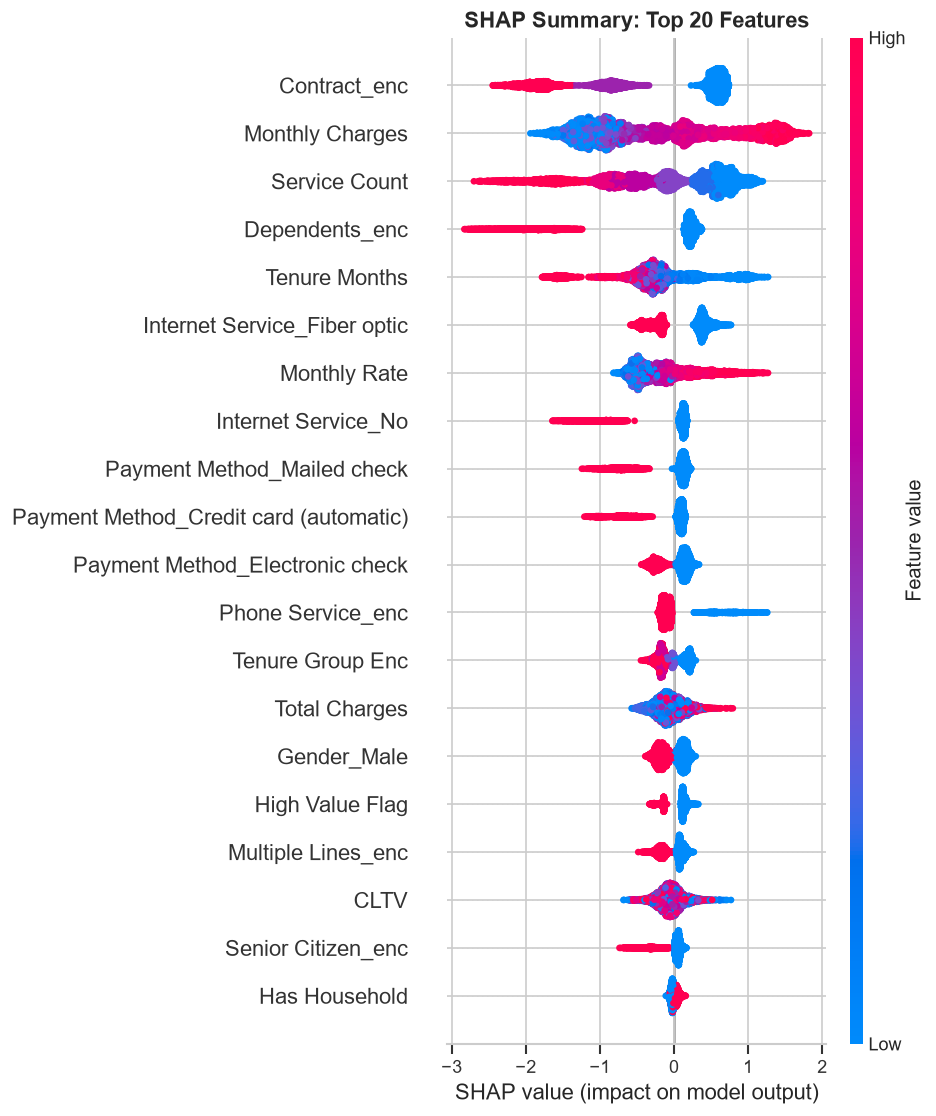

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type="dot",
                  max_display=20, show=False)
plt.title("SHAP Summary: Top 20 Features", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/18_shap_beeswarm.png", bbox_inches="tight")
plt.show()


**Key observations from the beeswarm:**

- **Contract type** (`Contract_enc`): Low values (month-to-month = 0) produce large positive
  SHAP values. Month-to-month customers are pushed strongly toward churn by the model.
  This is the dominant feature globally.
- **Tenure Months**: High tenure (red) produces negative SHAP values. Long-tenured customers
  are pushed away from churn. Low tenure (blue) pushes toward churn.
- **Monthly Charges / Monthly Rate**: High charges (red) push toward churn, consistent
  with the fiber optic finding in EDA.
- **Service Count**: High service count (red) pushes *away* from churn, confirming
  the switching-cost hypothesis from feature engineering.
- **CLTV**: Higher CLTV customers show positive SHAP values in some cases, reflecting
  that the model has learned the pattern of high-value customers being more at risk.


---
## 4. Mean Absolute SHAP Values: Global Importance Bar Chart

A cleaner view of aggregate importance for reporting and stakeholder communication.


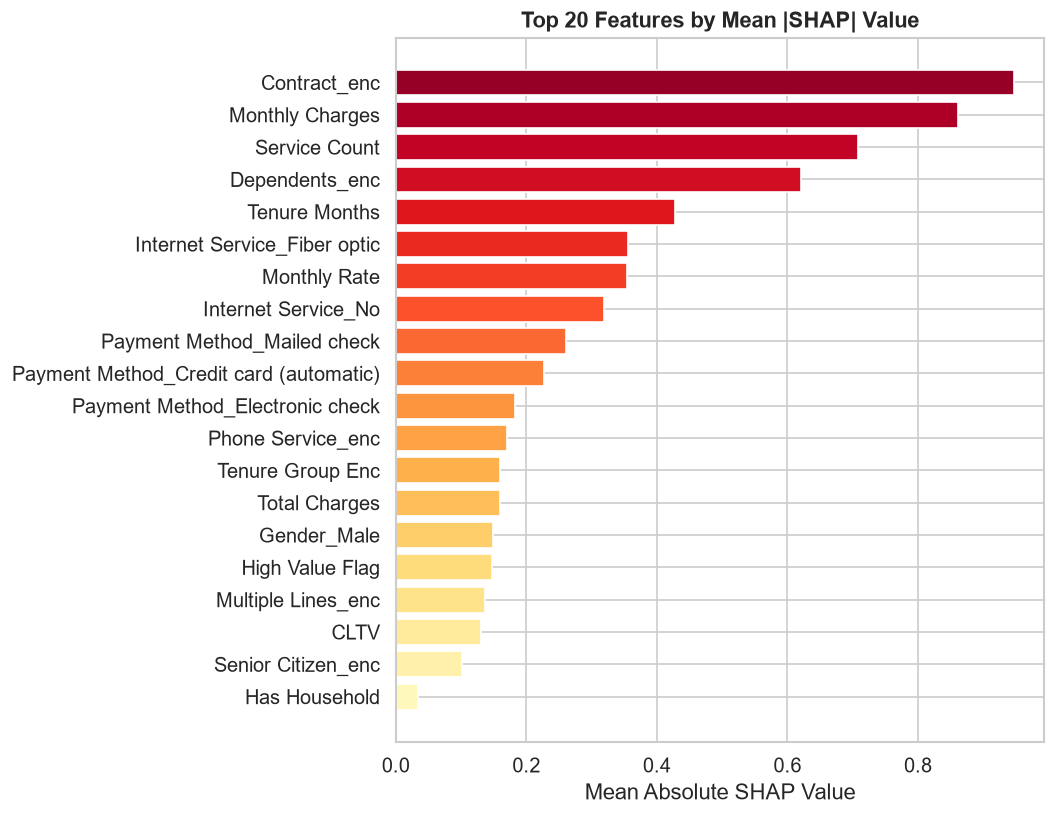

In [6]:
mean_shap = pd.DataFrame({
    "Feature"   : X.columns,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0),
}).sort_values("Mean |SHAP|", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("YlOrRd", len(mean_shap))
ax.barh(mean_shap["Feature"], mean_shap["Mean |SHAP|"],
        color=palette, edgecolor="white")
ax.set_title("Top 20 Features by Mean |SHAP| Value",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/19_shap_bar.png", bbox_inches="tight")
plt.show()


---
## 5. Dependence Plots: Top 4 Features

A dependence plot shows how the SHAP value for one feature changes as its
raw value changes, with color showing interaction with the most correlated feature.
This reveals non-linear relationships the model has learned.


Top 4 features for dependence plots: ['Contract_enc', 'Monthly Charges', 'Service Count', 'Dependents_enc']


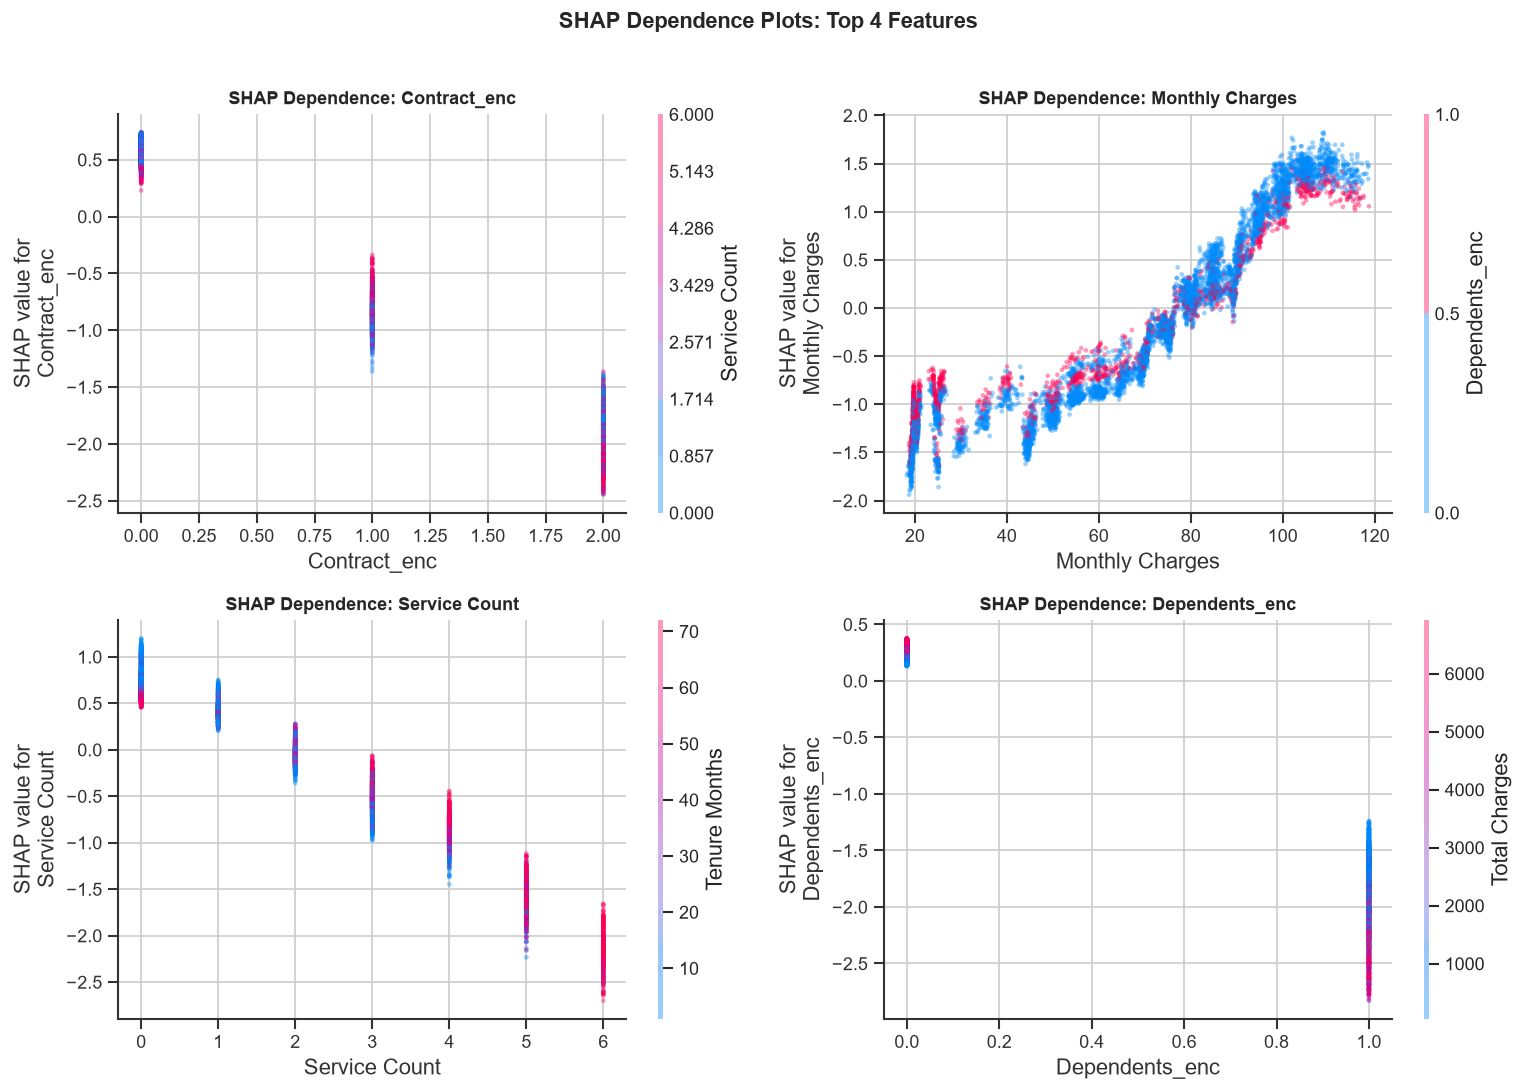

In [7]:
top4 = (pd.DataFrame({
    "Feature"   : X.columns,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0),
})
.sort_values("Mean |SHAP|", ascending=False)
.head(4)["Feature"]
.tolist())

print("Top 4 features for dependence plots:", top4)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(top4):
    shap.dependence_plot(
        feat, shap_values, X,
        ax=axes[i], show=False,
        dot_size=8, alpha=0.4
    )
    axes[i].set_title(f"SHAP Dependence: {feat}", fontweight="bold", fontsize=11)

plt.suptitle("SHAP Dependence Plots: Top 4 Features",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20_shap_dependence.png", bbox_inches="tight")
plt.show()


---
## 6. Individual Explanations: Waterfall Plots

Waterfall plots explain a single prediction. They show which features pushed
the score up (red, toward churn) and which pushed it down (blue, away from churn),
starting from the model baseline and arriving at the final predicted probability.

We examine two customers: the highest-risk and the lowest-risk in the dataset.


In [8]:
y_prob      = model.predict_proba(X)[:, 1]
threshold   = metadata["optimal_threshold"]

high_risk_idx = int(np.argmax(y_prob))
low_risk_idx  = int(np.argmin(y_prob))

print(f"Highest-risk customer index : {high_risk_idx}  |  P(churn) = {y_prob[high_risk_idx]:.3f}")
print(f"Lowest-risk  customer index : {low_risk_idx}   |  P(churn) = {y_prob[low_risk_idx]:.3f}")
print(f"Actual churn (high-risk)    : {y.iloc[high_risk_idx]}")
print(f"Actual churn (low-risk)     : {y.iloc[low_risk_idx]}")


Highest-risk customer index : 136  |  P(churn) = 0.984
Lowest-risk  customer index : 4001   |  P(churn) = 0.000
Actual churn (high-risk)    : 1
Actual churn (low-risk)     : 0


In [9]:
# High-risk customer profile
print("High-risk customer feature values:")
print(X.iloc[high_risk_idx].to_frame(name="Value").T.to_string())


High-risk customer feature values:
       Tenure Months  Monthly Charges  Total Charges    CLTV  Tenure Group Enc  Monthly Rate  Service Count  High Value Flag  Has Household  Partner_enc  Dependents_enc  Phone Service_enc  Paperless Billing_enc  Senior Citizen_enc  Multiple Lines_enc  Contract_enc  Internet Service_Fiber optic  Internet Service_No  Payment Method_Credit card (automatic)  Payment Method_Electronic check  Payment Method_Mailed check  Gender_Male
Value            1.0             85.0           85.0  5679.0               0.0          85.0            1.0              0.0            0.0          0.0             0.0                1.0                    1.0                 0.0                 1.0           0.0                           1.0                  0.0                                     0.0                              1.0                          0.0          0.0


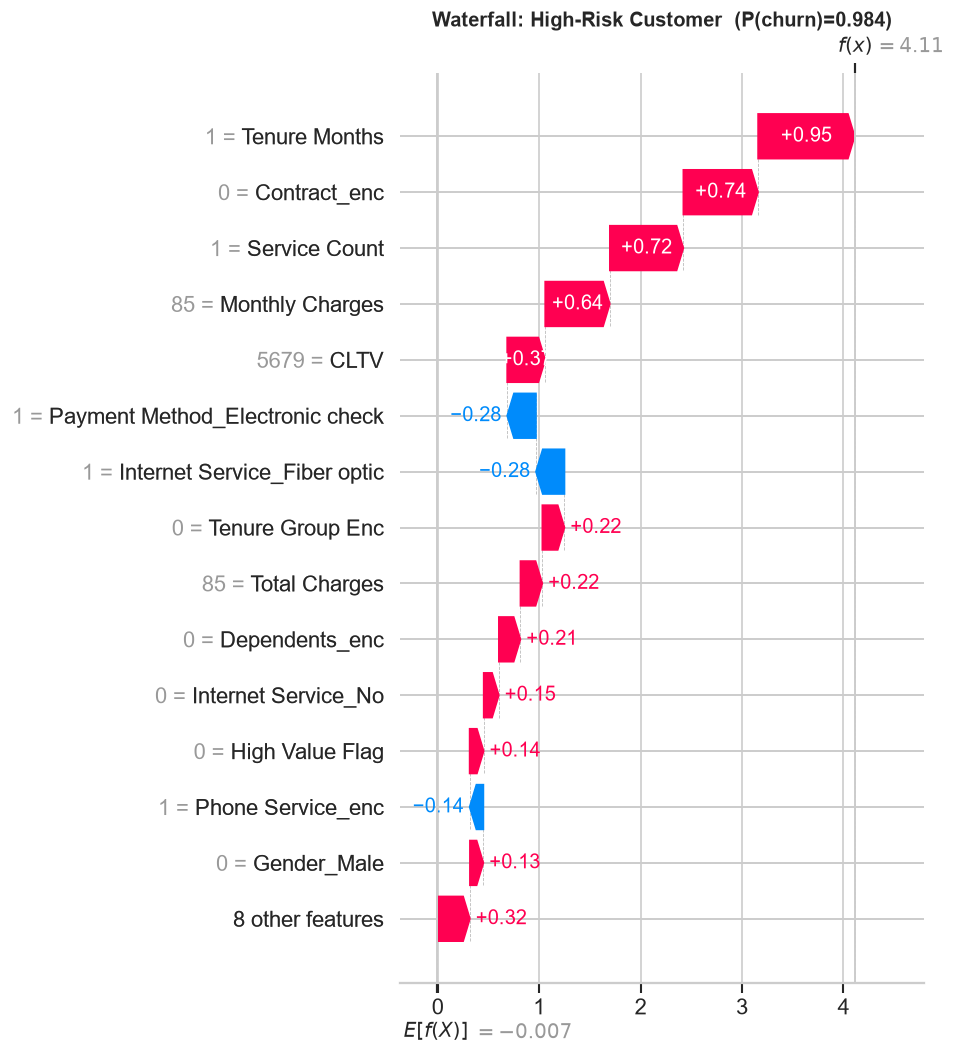

In [10]:
# Waterfall: high-risk customer
explanation_high = shap.Explanation(
    values         = shap_values[high_risk_idx],
    base_values    = explainer.expected_value,
    data           = X.iloc[high_risk_idx].values,
    feature_names  = X.columns.tolist(),
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(explanation_high, max_display=15, show=False)
plt.title(f"Waterfall: High-Risk Customer  (P(churn)={y_prob[high_risk_idx]:.3f})",
          fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/21_waterfall_high_risk.png", bbox_inches="tight")
plt.show()


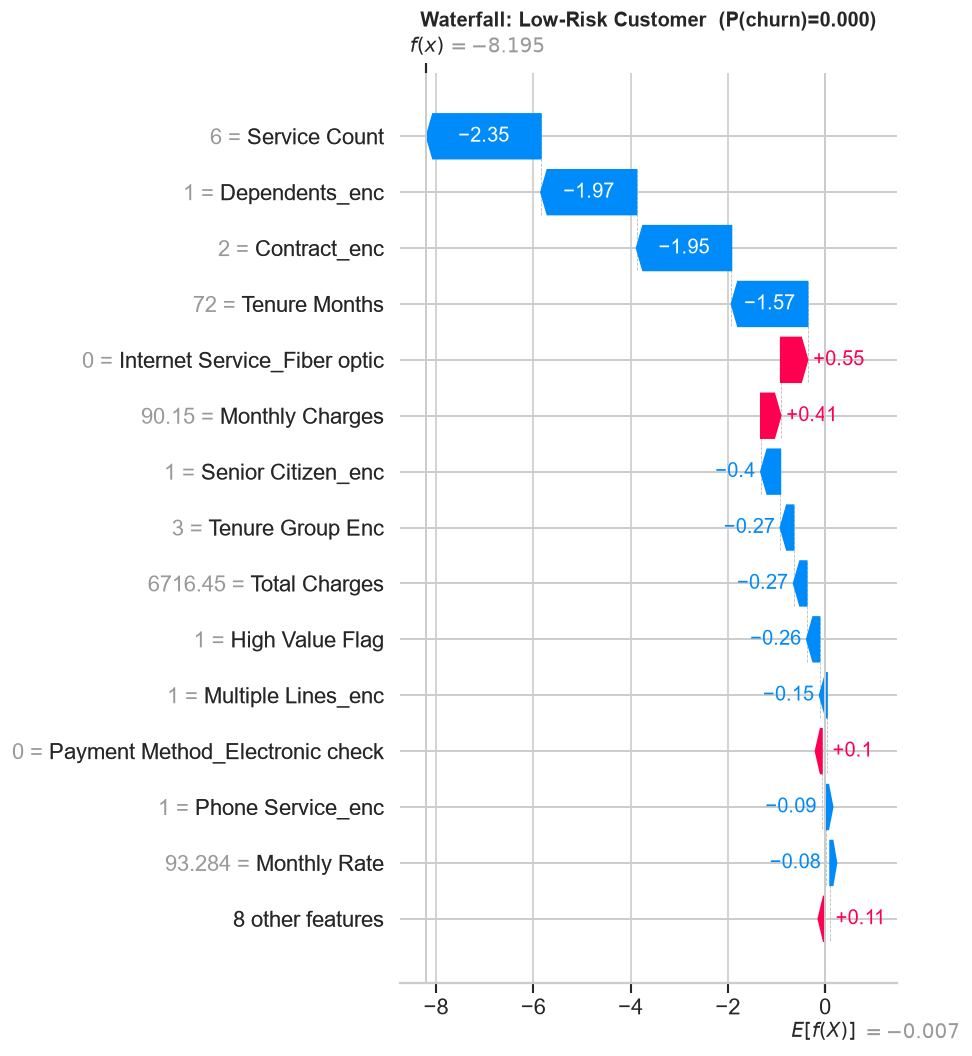

In [11]:
# Waterfall: low-risk customer
explanation_low = shap.Explanation(
    values         = shap_values[low_risk_idx],
    base_values    = explainer.expected_value,
    data           = X.iloc[low_risk_idx].values,
    feature_names  = X.columns.tolist(),
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(explanation_low, max_display=15, show=False)
plt.title(f"Waterfall: Low-Risk Customer  (P(churn)={y_prob[low_risk_idx]:.3f})",
          fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/22_waterfall_low_risk.png", bbox_inches="tight")
plt.show()


---
## 7. Segment-Level SHAP: High-Risk vs Low-Risk Customers

We split the dataset by predicted probability into a high-risk group (top 25%)
and a low-risk group (bottom 25%), then compare mean SHAP values to understand
what structurally differentiates the two segments.


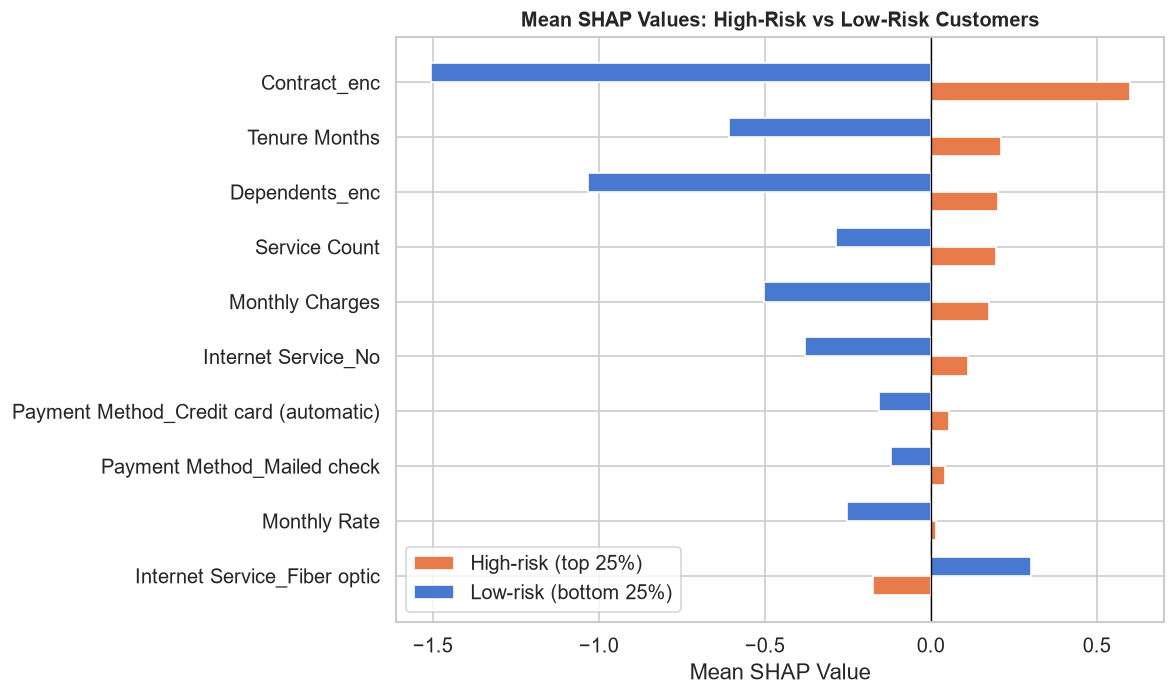

In [12]:
p75 = np.percentile(y_prob, 75)
p25 = np.percentile(y_prob, 25)

high_mask = y_prob >= p75
low_mask  = y_prob <= p25

shap_df = pd.DataFrame(shap_values, columns=X.columns)
shap_df["risk_group"] = "mid"
shap_df.loc[high_mask, "risk_group"] = "high"
shap_df.loc[low_mask,  "risk_group"] = "low"

top10_features = (mean_shap.tail(10)["Feature"].tolist())

seg_mean = (shap_df[shap_df["risk_group"].isin(["high","low"])]
            .groupby("risk_group")[top10_features]
            .mean()
            .T
            .sort_values("high", ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(seg_mean))
width = 0.35
ax.barh(x - width/2, seg_mean["high"], width,
        color="#E87B4A", label="High-risk (top 25%)")
ax.barh(x + width/2, seg_mean["low"],  width,
        color="#4878CF", label="Low-risk (bottom 25%)")
ax.set_yticks(x)
ax.set_yticklabels(seg_mean.index)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Mean SHAP Values: High-Risk vs Low-Risk Customers",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Mean SHAP Value")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/23_shap_segment_comparison.png", bbox_inches="tight")
plt.show()


**Interpretation:** The divergence between the two segments reveals the structural
differences the model has learned. Features with large positive SHAP in high-risk
customers and large negative SHAP in low-risk customers are the clearest differentiators.
Contract type and tenure will dominate this plot. Service count and household status
will appear on the protective (negative SHAP) side for low-risk customers.


---
## 8. Translating SHAP Findings into Business Actions

| SHAP Finding | Business Interpretation | Recommended Action |
|--------------|------------------------|-------------------|
| `Contract_enc` is the top driver. Low values (month-to-month) push churn probability up by +0.25 to +0.40. | Commitment level is the single largest controllable churn lever. | Offer contract upgrade incentives to month-to-month customers, especially in their first 12 months. |
| `Tenure Months` SHAP is strongly negative for long-tenured customers. | Survival past 24 months is a strong loyalty signal. | Early-tenure engagement programs have the highest ROI. Focus retention spend on customers under 12 months. |
| `Service Count` has negative SHAP for customers with 4+ services. | Add-on services create switching costs that protect against churn. | Bundle promotions for customers with 0-2 services are a low-cost retention lever. |
| `Monthly Charges` has positive SHAP at high values. | High-paying customers do not feel proportional value. | Review pricing for fiber optic tier. Consider loyalty discounts for high-charge, month-to-month customers. |
| `CLTV` shows positive SHAP for high-value customers. | The model has learned that high-value customers churn at higher rates. | Prioritise retention outreach by CLTV, not just churn probability. A 70% churn probability on a low-CLTV customer may cost less than a 45% probability on a high-CLTV customer. |

---
*Next step: `05_causal_inference.ipynb`. We go beyond correlation and ask whether
contract type causally reduces churn, using econml's double machine learning estimator.*
